# Multiple Linear Regression - Country Dataset

In [315]:
import pandas as pd # Veri analizi ve manipülasyonu için kullanılan bir kütüphane
import numpy as np # Sayısal işlemler ve dizilerle çalışmak için kullanılan bir kütüphane
import seaborn as sns # Veri görselleştirme için kullanılan bir kütüphane
import matplotlib.pyplot as plt # Grafik çizimi için kullanılan bir kütüphane
import statsmodels.api as sm # İstatistiksel modeller ve analizler için kullanılan bir kütüphane

from statsmodels.stats.diagnostic import het_breuschpagan # Breusch-Pagan testi, regresyon modellerinde heteroskedastisite (değişen varyans) olup olmadığını test etmek için kullanılan bir istatistiksel testtir. 
# Bu test, modelin hata terimlerinin varyansının sabit olup olmadığını değerlendirir. 
# Eğer heteroskedastisite varsa, bu durum modelin tahminlerinin güvenilirliğini etkileyebilir ve standart hataların yanlış hesaplanmasına neden olabilir. 
# Breusch-Pagan testi, bu durumu tespit etmek için kullanılır ve sonuçları, modelin doğruluğunu değerlendirmek için önemlidir.

from statsmodels.stats.outliers_influence import variance_inflation_factor # Varyans Enflasyon Faktörü (VIF), regresyon modellerinde çoklu doğrusal ilişki (multicollinearity) olup olmadığını değerlendirmek için kullanılan bir istatistiksel ölçüdür. 
# VIF, her bir bağımsız değişkenin diğer bağımsız değişkenlerle ne kadar ilişkili olduğunu ölçer. 
# Yüksek VIF değerleri, bir bağımsız değişkenin diğer bağımsız değişkenlerle yüksek derecede ilişkili olduğunu gösterir ve bu durum modelin tahminlerinin güvenilirliğini etkileyebilir. 
# Genellikle, VIF değeri 10'un üzerinde olan değişkenler çoklu doğrusal ilişki sorununa işaret eder ve bu değişkenlerin modelden çıkarılması veya dönüştürülmesi gerekebilir.

from sklearn.model_selection import train_test_split # Veriyi eğitim ve test setlerine bölmek için kullanılan bir fonksiyon. 
# Bu fonksiyon, veri setini rastgele bir şekilde belirli bir oranda eğitim ve test setlerine ayırır. 
# Genellikle, veri setinin %70-80'i eğitim seti olarak kullanılırken, geri kalan %20-30'u test seti olarak kullanılır. 
# Bu, modelin performansını değerlendirmek için önemlidir, çünkü modelin eğitildiği verilerle test edildiği verilerin farklı olması, modelin genelleme yeteneğini ölçmek için gereklidir.

from sklearn.preprocessing import StandardScaler # Veriyi standartlaştırmak için kullanılan bir araç. 
# Standartlaştırma, verilerin ortalamasını 0 ve standart sapmasını 1 yaparak verileri ölçeklendirir. 
# Bu, özellikle regresyon modellerinde, farklı ölçeklerdeki değişkenlerin etkisini dengelemek ve modelin performansını artırmak için önemlidir.

from sklearn.linear_model import Ridge, Lasso, ElasticNet # Ridge, Lasso ve ElasticNet regresyon modelleri, çoklu doğrusal regresyon problemlerinde kullanılan düzenlileştirme (regularization) teknikleridir. 
# Bu modeller, modelin karmaşıklığını kontrol etmek ve aşırı uyum (overfitting) sorununu azaltmak için kullanılır. 
# Ridge regresyonu, modelin katsayılarını küçültmek için L2 düzenlileştirmesi kullanılır, 
# Lasso regresyonu L1 düzenlileştirmesi kullanarak bazı katsayıları sıfıra indirerek değişken seçimi yapabilir. 
# ElasticNet ise her iki düzenlileştirme tekniğini birleştirerek daha esnek bir model sağlar. 
# Bu modeller, özellikle yüksek boyutlu veri setlerinde ve çoklu doğrusal ilişkilerin olduğu durumlarda etkili olabilir.

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error # Model performansını değerlendirmek için kullanılan metrikler. 
# R2 skoru, modelin bağımsız değişkenlerin varyansını ne kadar açıkladığını ölçerken, mean absolute error (MAE) ve mean squared error (MSE) ise modelin tahminlerinin gerçek değerlerden ne kadar sapma gösterdiğini ölçer. 
# MAE, tahmin hatalarının mutlak değerlerinin ortalamasını alırken, MSE tahmin hatalarının karelerinin ortalamasını alır. 
# Bu metrikler, modelin doğruluğunu ve performansını değerlendirmek için kullanılır.

In [316]:
sns.set_style('darkgrid')  # Grafiklerin arka plan stilini 'darkgrid' olarak ayarlar.

In [317]:
df = pd.read_csv('data/Country.csv') # 'data/Country.csv' dosyasından veri setini yükler ve df adlı bir DataFrame oluşturur. 
#Bu DataFrame, ülkelerle ilgili çeşitli bilgileri içerebilir ve bu bilgiler, veri analizi ve modelleme süreçlerinde kullanılabilir. 

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,Gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [318]:
df.drop(
    columns=['country'],
    axis=1,
    inplace=True
) # 'country' sütununu DataFrame'den kaldırır. Bu sütun, modelleme sürecinde kullanılmayacaksa veya modelin performansını artırmak için gereksizse kaldırılır.

df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,Gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [319]:
# Veri setindeki her bir sütunda eksik değerlerin sayısını gösterir. 
# Eksik değerler, veri setindeki boş veya null değerlerdir ve modelin performansını etkileyebilir. 
# Bu nedenle, veri setindeki eksik değerlerin sayısını kontrol etmek önemlidir.

df.isnull().sum() # Veri setindeki her bir sütunda eksik değerlerin sayısını gösterir.

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
Gdpp          0
dtype: int64

In [320]:
# Veri setindeki her bir sütunun veri tipini gösterir. 
# Bu, veri setindeki değişkenlerin türlerini anlamamıza yardımcı olur. 
# Örneğin, sayısal değişkenler genellikle int veya float türünde olurken, kategorik değişkenler genellikle object türünde olur.

df.dtypes.to_frame(name='dtype')  # Veri setindeki her bir sütunun veri tipini gösterir.

,dtype
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
Gdpp,int64


In [321]:
df.duplicated().sum() # Veri setinde eden satırlar, yani veri setinde tekrar eden kayıtların bulunup bulunmadığını kontrol eder. Eğer veri setinde tekrar eden kayıtlar varsa, bu kayıtlar modelin performansını olumsuz etkileyebilir ve yanıltıcı sonuçlara yol açabilir. Bu nedenle, veri setindeki tekrar eden kayıtların sayısını kontrol etmek önemlidir.

0

In [322]:
# Veri setindeki her bir sütunun benzersiz değer sayısını gösterir. 
# Bu, veri setindeki kategorik ve sürekli değişkenlerin sayısını anlamamıza yardımcı olur. 
# Benzersiz değer sayısı düşük olan sütunlar genellikle kategorik değişkenlerdir, benzersiz değer sayısı yüksek olan sütunlar ise genellikle sürekli değişkenlerdir.

df.nunique().sort_values()  # Veri setindeki her bir sütunun benzersiz değer sayısını gösterir.

life_expec    127
total_fer     138
child_mort    139
exports       147
health        147
imports       151
income        156
inflation     156
Gdpp          157
dtype: int64

In [323]:
df.shape # Veri setinin satır ve sütun sayısını gösterir. df.shape[0] satır sayısını, df.shape[1] ise sütun sayısını verir.

(167, 9)

In [324]:
df.corr() # Veri setindeki sayısal değişkenler arasındaki korelasyon matrisini hesaplar. 
# Korelasyon matrisi, değişkenler arasındaki doğrusal ilişkiyi gösterir ve -1 ile 1 arasında değerler alır. 
# 1'e yakın değerler güçlü pozitif korelasyonu, -1'e yakın değerler güçlü negatif korelasyonu ve 0'a yakın değerler ise zayıf veya hiç korelasyonu gösterir.

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,Gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
Gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


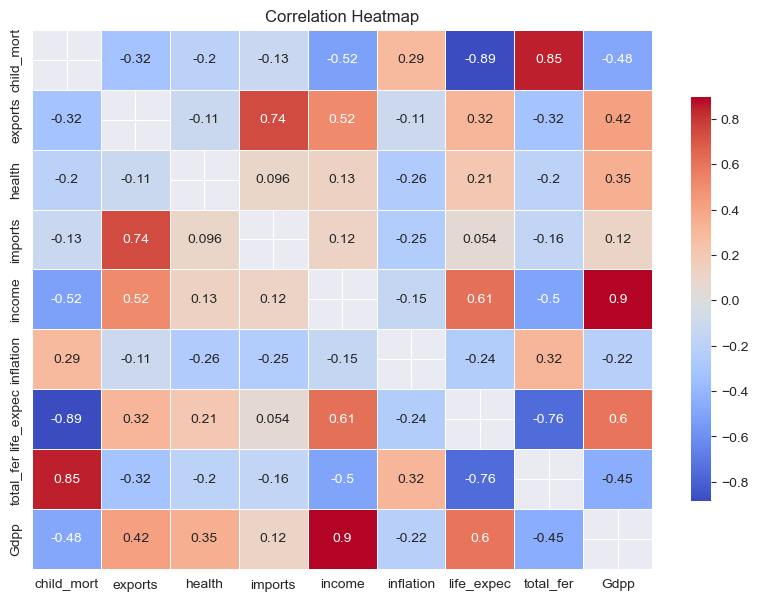

In [325]:
corr = df.corr() # Veri setindeki sayısal değişkenler arasındaki korelasyon matrisini hesaplar. 

np.fill_diagonal(corr.values, np.nan) # Korelasyon matrisinin köşegenindeki değerleri NaN yapar.

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'shrink': 0.75
    } 
)

plt.title('Correlation Heatmap')
plt.show()

In [326]:
df.corr()['Gdpp'].sort_values(ascending=False) # 'Gdpp' sütunu ile diğer sayısal değişkenler arasındaki korelasyonu hesaplar ve sonuçları azalan sırayla gösterir.

Gdpp          1.000000
income        0.895571
life_expec    0.600089
exports       0.418725
health        0.345966
imports       0.115498
inflation    -0.221631
total_fer    -0.454910
child_mort   -0.483032
Name: Gdpp, dtype: float64

In [327]:
# VIF (Variance Inflation Factor)

# Feature data set oluşturalım
X_features = df.drop(columns=['Gdpp'])

# VIF (Variance Inflation Factor), regresyon modellerinde çoklu doğrusal bağlantıyı (multicollinearity) tespit etmek için kullanılan bir ölçüdür. 
# VIF değeri, bir özelliğin diğer özelliklerle ne kadar ilişkili olduğunu gösterir. 
# Yüksek VIF değerleri, o özelliğin diğer özelliklerle yüksek korelasyona sahip olduğunu ve modelde çoklu doğrusal bağlantının var olduğunu gösterebilir. 
# Genellikle, VIF değeri 5 veya 10'un üzerinde olan özellikler, çoklu doğrusal bağlantıya sahip olarak kabul edilir ve modelden çıkarılması veya dönüştürülmesi gerekebilir.

# VIF hesaplamak için, her bir özelliğin diğer özelliklerle regresyonunu yaparak R² değerini hesaplarız ve ardından VIF formülünü kullanarak VIF değerini elde edilir.
# VIF formülü: VIF = 1 / (1 - R²)
# VIF değerlerini hesaplamak için statsmodels kütüphanesindeki variance_inflation_factor fonksiyonunu kullanırız.
# Bu fonksiyon, her bir özelliğin VIF değerini hesaplamak için kullanılır.

# VIF Tablosu
vif_data = pd.DataFrame()
vif_data['feature'] = X_features.columns
vif_data['VIF Score'] = [
    variance_inflation_factor(X_features.values, i) # Her bir özelliğin VIF değerini hesaplar. X_features.values, özelliklerin değerlerini içeren bir NumPy dizisi olarak alınır. i, her bir özelliğin indeksini temsil eder.
    for i in range(len(X_features.columns))
]

vif_data.sort_values(by='VIF Score', ascending=False)

,feature,VIF Score
6,life_expec,20.033757
7,total_fer,17.652689
3,imports,17.078102
1,exports,16.008933
2,health,9.832297
0,child_mort,8.060881
4,income,4.282023
5,inflation,1.942327


In [328]:
X = df.drop(columns=['Gdpp']) # Bağımsız değişkenler

y = df['Gdpp'] # Bağımlı değişken

In [329]:
X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13


In [330]:
y[0:5]  # İlk 5 gözlem

0      553
1     4090
2     4460
3     3530
4    12200
Name: Gdpp, dtype: int64

In [331]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # Verinin %20'sini test seti olarak ayırıyoruz
    random_state=42 # Rastgelelik için bir seed değeri belirliyoruz 
)  # Veriyi eğitim ve test setlerine ayırıyoruz

In [332]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape  # Eğitim ve test setlerinin boyutları 

((133, 8), (34, 8), (133,), (34,))

In [333]:
scaler = StandardScaler() # StandardScaler ile özellikler ölçeklendirilir. 
# StandardScaler, özelliklerin ortalamasını 0 ve standart sapmasını 1 yaparak veriyi standartlaştırır. 

X_train_scaled = scaler.fit_transform(X_train) # Eğitim verisini ölçeklendirelim
X_test_scaled = scaler.transform(X_test) # Test verisini ölçeklendirelim

In [334]:
X_train_scaled # Ölçeklendirilmiş eğitim verisi

array([[-0.83746628, -0.46960119,  1.02705834, ..., -0.59499747,
         1.1087671 , -0.70605991],
       [-0.29757844, -0.03846097, -0.99004398, ...,  0.67078917,
         0.68784703, -0.08237768],
       [-0.598059  ,  0.50257773, -0.31521816, ..., -0.63332824,
         0.34446486, -0.93109988],
       ...,
       [-0.83013748,  0.51103146, -0.4590335 , ...,  0.58367378,
         0.01215954, -0.98253759],
       [-0.71043384,  0.02071513,  0.08672728, ..., -0.55405324,
         0.41092593, -0.99539702],
       [-0.54431451, -0.00464606,  1.78669834, ...,  0.23521221,
        -0.06537837, -1.12399129]])

In [335]:
# Statsmodels cütüphanesi ile OLS (Ordinary Least Squares) regresyon modelini oluşturmak için, ölçeklendirilmiş eğitim verisine sabit terim eklenir. 
# Sabit terim, regresyon modelinde kesme noktasını temsil eder ve genellikle 1'ler sütunu olarak eklenir. 
# Bu, modelin bağımsız değişkenlerin etkisini daha doğru bir şekilde değerlendirmesine yardımcı olur.
# Modelin matris formunda ifade edilmesi için, bağımsız değişkenlerin ölçeklendirilmiş versiyonuna sabit terim eklenir.

X_train_sm = sm.add_constant(X_train_scaled) # Statsmodels ile regresyon modelini oluşturmak için sabit terim ekler
X_test_sm = sm.add_constant(X_test_scaled) # Test verisine de sabit terim ekler

In [336]:
# OLS (Ordinary Least Squares) regresyon modeli, Statsmodels kütüphanesi ile calıştırılabilir. 
# OLS, bağımsız değişkenlerin bağımlı değişken üzerindeki etkisini ölçmek için kullanılan bir regresyon tekniğidir. 
# Bu mmodelin cıktısı, her bir bağımsız değişkenin katsayılarını, standart hatalarını, t-istatistiklerini ve p-değerlerini içerir.
# OLS modelini eğitmek için, bağımlı değişken (y_train) ve bağımsız değişkenler (X_train_sm) kullanılır.

ols = sm.OLS(y_train, X_train_sm).fit() # OLS (Ordinary Least Squares) regresyon modelini eğitir

print(ols.summary()) # Regresyon modelinin özetini görüntüler

# Hata --> y - y^

                            OLS Regression Results                            
Dep. Variable:                   Gdpp   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     101.3
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.19e-50
Time:                        00:24:00   Log-Likelihood:                -1365.3
No. Observations:                 133   AIC:                             2749.
Df Residuals:                     124   BIC:                             2775.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.321e+04    624.340     21.154      0.0

In [337]:
y_pred = ols.predict(X_test_sm) # Test seti için tahminler yapar

r2 = r2_score(y_test, y_pred) # R2 skorunu hesaplar
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test_sm.shape[1] - 1) # Adjusted R2 hesaplar
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # RMSE hesaplar
mae = mean_absolute_error(y_test, y_pred) # MAE hesaplar

print(
    f'Test R2: {r2:.4f}\n'
    f'Test Adjusted R2: {adjusted_r2:.4f}\n'
    f'Test RMSE: {rmse:.2f}\n'
    f'Test MAE: {mae:.2f}'
)

Test R2: 0.8268
Test Adjusted R2: 0.7618
Test RMSE: 6091.22
Test MAE: 4690.96


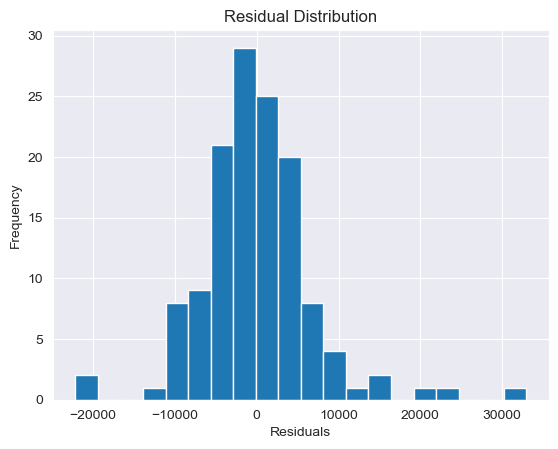

In [338]:
# Modelin varsayımlarını değerlendirmek için residuals (hatalar) analizi yapılır.
# Residuals (hatalar), modelin tahmin ettiği değerler ile gerçek değerler arasındaki farklardır.
# Residuals (hatalar) analizi, modelin varsayımlarını değerlendirmek için kullanılır.
# Normal dağılım varsayımı, homoskedastisite ve bağımsızlık gibi varsayımların kontrol edilmesine yardımcı olur.
# Eğer residuals (hatalar) normal dağılıyorsa, modelin varsayımları büyük ölçüde sağlanmış demektir.

residuals= y_train - ols.predict(X_train_sm) # Eğitim seti için tahminler yapar ve residuals (hatalar) hesaplanır

plt.hist(residuals, bins=20) # Residuals (hatalar) dağılımını görselleştirmek için histogram çizilir 
plt.title('Residual Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

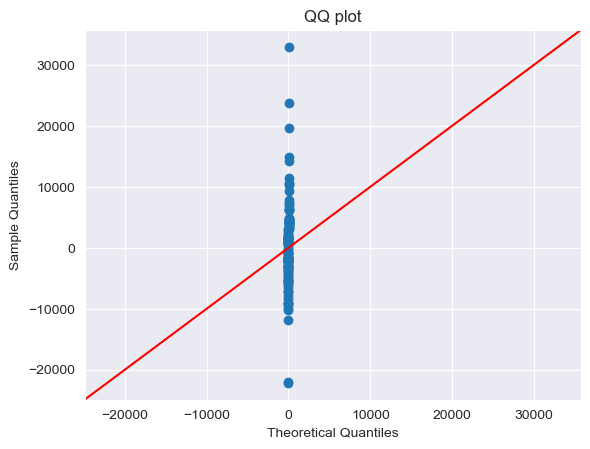

In [339]:
sm.qqplot(residuals, line='45') # QQ plot, residuals (hatalar) dağılımının normal dağılıma uygunluğunu görselleştirmek için kullanılır.
plt.title('QQ plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

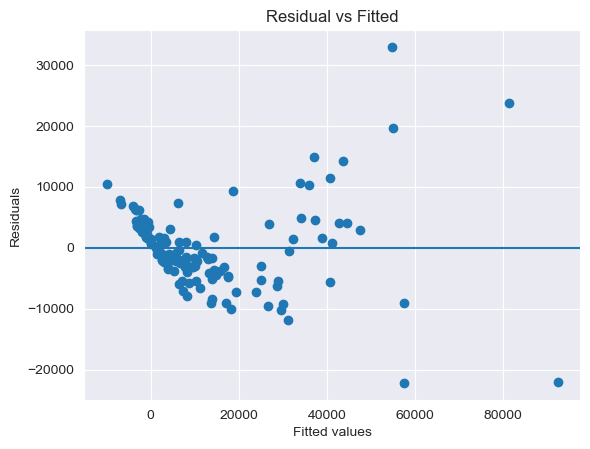

In [340]:
plt.scatter(ols.predict(X_train_sm), residuals) # Residuals (hatalar) vs Fitted (tahminler) grafiği, modelin varsayımlarını değerlendirmek için kullanılır.

plt.axhline(0) # Yatay çizgi ekleyerek residuals (hatalar) değerlerinin sıfır etrafında dağılıp dağılmadığını görselleştirir
plt.title('Residual vs Fitted')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

In [341]:
# Breusch-Pagan testi, regresyon modelindeki heteroskedastisiteyi (değişen varyans) test etmek için kullanılır.
# Heteroskedastisite, modelin hata terimlerinin sabit bir varyansa sahip olmaması durumudur.
# Eğer p-değeri küçükse (genellikle 0.05'ten küçük), heteroskedastisite vardır ve modelin hata terimleri sabit bir varyansa sahip değildir.
# Eğer p-değeri büyükse, heteroskedastisite yoktur ve modelin hata terimleri sabit bir varyansa sahiptir.

bp = het_breuschpagan(residuals, X_train_sm) # Breusch-Pagan testi, regresyon modelindeki heteroskedastisiteyi (değişen varyans) test etmek için kullanılır.

print(
    f'LM p-value: {bp[1]}\n' # LM (Lagrange Multiplier) testi, Breusch-Pagan testinin bir parçasıdır ve heteroskedastisitenin varlığını test eder. p-değeri küçükse, heteroskedastisite vardır.
    f'F p-value: {bp[3]}' # F testi, Breusch-Pagan testinin bir parçasıdır ve heteroskedastisitenin varlığını test eder. p-değeri küçükse, heteroskedastisite vardır.
)

LM p-value: 1.6871001238117321e-10
F p-value: 4.794144011492166e-14


In [342]:
# Heteroskedastisite varsa, OLS modelinin standart hataları güvenilir olmayabilir. Bu durumda, heteroskedastisiteye dayanıklı standart hatalar kullanarak modelin sonuçlarını yeniden değerlendirmek önemlidir.
# Robust standart hatalar, modelin heteroskedastisiteye karşı dayanıklı hale gelmesini sağlar ve böylece modelin sonuçlarının güvenilirliğini artırır.
# Bu yöntem, özellikle heteroskedastisite mevcut olduğunda modelin katsayılarının standart hatalarını daha doğru bir şekilde tahmin eder.

# Heteroskedastisiteye dayanıklı standart hatalar kullanarak modelin sonuçlarını yeniden değerlendirmek, modelin güvenilirliğini artırır ve daha doğru sonuçlar elde edilmesini sağlar.

ols_robust = ols.get_robustcov_results(cov_type='HC3') # Heteroskedastisiteye dayanıklı standart hatalar kullanarak modelin sonuçları yeniden değerlendirilir

print(ols_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                   Gdpp   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     34.91
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           2.59e-28
Time:                        00:24:00   Log-Likelihood:                -1365.3
No. Observations:                 133   AIC:                             2749.
Df Residuals:                     124   BIC:                             2775.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.321e+04    712.104     18.547      0.0

In [343]:
# Ridge Regression, Lasso Regression ve Elastic Net gibi düzenlileştirme teknikleri, modelin aşırı öğrenmesini (overfitting) önlemek ve modelin genelleme yeteneğini artırmak için kullanılır.

# Ridge Regression, L2 düzenlileştirme tekniğini kullanarak modelin katsayılarını küçülterek aşırı öğrenmesini önler ve böylece modelin genelleme yeteneğini artırır.

ridge = Ridge(alpha=1.0) # Ridge Regression modelini oluşturur, alpha parametresi düzenlileştirme gücünü kontrol eder. Daha yüksek alpha değerleri, daha fazla düzenlileştirme uygular ve katsayıları daha fazla küçültür.
ridge.fit(X_train_scaled, y_train) 
ridge_pred = ridge.predict(X_test_scaled)

print(
    f'RIDGE\n'
    f'R2: {r2_score(y_test, ridge_pred)}\n'
    f'Adjusted R2: {1 - (1 - r2_score(y_test, ridge_pred)) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1):.4f}\n'
    f'RMSE: {np.sqrt(mean_squared_error(y_test, ridge_pred))}\n'
    f'MAE: {mean_absolute_error(y_test, ridge_pred)}'
)

RIDGE
R2: 0.8299355231213902
Adjusted R2: 0.7755
RMSE: 6035.483533325702
MAE: 4663.912395603623


In [344]:
# Lasso Regression, modelin katsayılarını küçülterek aşırı öğrenmeyi önler ve böylece modelin genelleme yeteneğini artırır.
# L1 düzenlileştirme, bazı katsayıları sıfıra indirerek değişken seçimi yapar ve modelin daha basit ve yorumlanabilir olmasını sağlar.

lasso = Lasso(alpha=0.1) # Lasso Regression modelini oluşturur, alpha parametresi düzenlileştirme gücünü kontrol eder. Daha yüksek alpha değerleri, daha fazla düzenlileştirme uygular ve katsayıları daha fazla küçültür.
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

print(
    f'LOSSO\n'
    f'R2: {r2_score(y_test, lasso_pred)}\n'
    f'Adjusted R2: {1 - (1 - r2_score(y_test, lasso_pred)) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1):.4f}\n'
    f'RMSE: {np.sqrt(mean_squared_error(y_test, lasso_pred))}\n'
    f'MAE: {mean_absolute_error(y_test, lasso_pred)}'
)

LOSSO
R2: 0.8267909119442665
Adjusted R2: 0.7714
RMSE: 6091.028101809113
MAE: 4690.77751359538


In [345]:
# Elastic Net, L1 ve L2 düzenlileştirme tekniklerini birleştirerek modelin katsayılarını küçültür ve böylece modelin aşırı öğrenmesini önler.
# L1 ve L2 düzenlileştirme oranını belirlemek için l1_ratio parametresi kullanılır. l1_ratio=0.5, L1 ve L2 düzenlileştirmeyi eşit ağırlıkta uygular.

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5) # Elastic Net modelini oluşturur, alpha parametresi düzenlileştirme gücünü kontrol eder. Daha yüksek alpha değerleri, daha fazla düzenlileştirme uygular ve katsayıları daha fazla küçültür. l1_ratio parametresi, L1 ve L2 düzenlileştirme oranını belirler. l1_ratio=0.5, L1 ve L2 düzenlileştirmeyi eşit ağırlıkta uygular.
elastic.fit(X_train_scaled, y_train)
elastic_pred = elastic.predict(X_test_scaled)

print(
    f'ELASTIC\n'
    f'R2: {r2_score(y_test, elastic_pred)}\n'
    f'Adjusted R2: {1 - (1 - r2_score(y_test, elastic_pred)) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1):.4f}\n'
    f'RMSE: {np.sqrt(mean_squared_error(y_test, elastic_pred))}\n'
    f'MAE: {mean_absolute_error(y_test, elastic_pred)}'
)

ELASTIC
R2: 0.841335206432158
Adjusted R2: 0.7906
RMSE: 5829.691205695285
MAE: 4578.842374149513


In [346]:
# coefficient değerlerini karşılaştırmak için bir DataFrame oluşturulur. Bu DataFrame, her bir özelliğin Ridge, Lasso ve Elastic Net modellerindeki katsayılarını içerir.
# Bu karşılaştırma, hangi özelliklerin hangi modellerde daha önemli olduğunu ve hangi modellerin hangi özellikleri daha fazla küçülttüğünü görselleştirmeye yardımcı olur.
coef_df = pd.DataFrame({
    'feature': X.columns,
    'ridge': ridge.coef_,
    'lasso': lasso.coef_,
    'elastic': elastic.coef_
})

coef_df.sort_values(by='elastic', key=abs, ascending=False)

,feature,ridge,lasso,elastic
4,income,15145.312608,15344.347110,14150.142847
2,health,4666.511181,4667.196945,4600.356261
6,life_expec,3905.725895,4069.723331,3353.189216
0,child_mort,3374.523857,3643.788773,2360.142058
1,exports,1507.892918,1386.366069,1968.933079
5,inflation,-927.588857,-921.407969,-937.191772
7,total_fer,841.518487,809.623644,860.194314
3,imports,-427.765944,-340.757431,-722.015253
